In [1]:
# !pip install anomalib
# !pip install matplotlib
# !pip install numpy
# !pip install tensorboard
# !pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu128
# !pip install kaggle


In [2]:
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as torch_f
from torch.optim.lr_scheduler import MultiStepLR

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from anomalib.metrics.aupro import _AUPRO as DirectAUPRO
from anomalib.models.image.supersimplenet.loss import SSNLoss
from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel

# import warnings
# warnings.filterwarnings('ignore')


c:\Users\AERO\Desktop\master_work\Experiments\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
import torch

print("Python executable:", sys.executable)
print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))

assert "+cu128" in torch.__version__, "Expected CUDA 12.8 PyTorch wheel, e.g. torch==2.7.1+cu128"
assert torch.cuda.is_available(), "CUDA is not visible from this notebook kernel"


Python executable: c:\Users\AERO\Desktop\master_work\Experiments\.venv\Scripts\python.exe
torch: 2.7.1+cu128
torch.version.cuda: 12.8
cuda available: True
cuda device: NVIDIA GeForce RTX 3070 Ti Laptop GPU


# Конфигурация

Основные метрики качества: `image_roc_auc_raw` для image-level detection и `pixel_aupro` для localization/segmentation. Они используются для валидации и финальной оценки.


Для предобработки картинок и постобработке карт аномалий


In [4]:
dataset_path = os.path.join("../datasets", "MVTecAD")
class_name = "metal_nut"
test_groups = None
image_size = 256
quality_metric_names = ["image_roc_auc_raw", "pixel_aupro"]


In [5]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.9, 1.0), ratio=(1, 1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_mask_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ])


def denormalize_image(tensor):
    denormalize = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )
    return torch.clamp(denormalize(tensor.detach().cpu()), 0.0, 1.0)


def show_tensor(tensor):
    transforms.ToPILImage()(tensor.detach().cpu()).show()


def postprocess_anomaly_map(anomaly_map, true_img_size):
    while anomaly_map.ndim < 4:
        anomaly_map = anomaly_map.unsqueeze(0)

    upsampled_mask = torch_f.interpolate(
        anomaly_map,
        size=true_img_size,
        mode="bilinear",
        align_corners=False,
    )
    return upsampled_mask.squeeze()


In [6]:
# path = os.path.join(dataset_path, class_name, "test", test_groups[0], "003.png")
# print(path)
# img = Image.open(path).convert('RGB')
# img = get_transformer(256)(img)
# print(img.shape)
# # img = img[0, :, :]
# img = postprocess_anomaly_map(img.unsqueeze(0), true_img_size=(900, 900))
# print(img.shape)
# print(img.max())
# print(img.dtype)
# show_tensor(img)


Датасеты


In [7]:
class Train_Dataset(Dataset):
    def __init__(self, root_dir, category, transform=None, split="train", good_class_dir="good"):
        self.root_dir = os.path.join(root_dir, category, split)
        self.transform = transform
        self.image_paths = []

        good_path = os.path.join(self.root_dir, good_class_dir)
        if os.path.isdir(good_path):
            for img_name in sorted(os.listdir(good_path)):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.image_paths.append(os.path.join(good_path, img_name))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


class Segmentation_Dataset(Dataset):
    def __init__(
        self,
        root_dir,
        category,
        img_transform=None,
        mask_transform=None,
        imgs_dir="test",
        test_classes=None,
        masks_dir="ground_truth",
        good_class_dir="good",
        strict_masks=True,
    ):
        self.img_transform = img_transform
        self.mask_transform = mask_transform
        self.base_transform = transforms.ToTensor()
        test_classes = set(test_classes or [])

        imgs_path = os.path.join(root_dir, category, imgs_dir)
        masks_path = os.path.join(root_dir, category, masks_dir)
        image_paths = []
        mask_paths = []
        defect_types = []
        image_names = []
        missing_masks = []

        for defect_type in sorted(os.listdir(imgs_path)):
            if test_classes and defect_type not in test_classes:
                continue
            if defect_type == good_class_dir:
                continue

            class_path = os.path.join(imgs_path, defect_type)
            if not os.path.isdir(class_path):
                continue

            mask_class_path = os.path.join(masks_path, defect_type)
            for img_name in sorted(os.listdir(class_path)):
                if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                image_path = os.path.join(class_path, img_name)
                stem, ext = os.path.splitext(img_name)
                candidate = os.path.join(mask_class_path, f"{stem}_mask{ext}")
                mask_path = candidate if os.path.exists(candidate) else None

                if mask_path is None and os.path.isdir(mask_class_path):
                    mask_stem = f"{stem}_mask"
                    for mask_name in sorted(os.listdir(mask_class_path)):
                        if os.path.splitext(mask_name)[0] == mask_stem:
                            mask_path = os.path.join(mask_class_path, mask_name)
                            break

                if mask_path is None:
                    missing_masks.append(image_path)
                    continue

                image_paths.append(image_path)
                mask_paths.append(mask_path)
                defect_types.append(defect_type)
                image_names.append(img_name)

        if missing_masks and strict_masks:
            preview = "\n".join(missing_masks[:5])
            extra = "" if len(missing_masks) <= 5 else f"\n... and {len(missing_masks) - 5} more"
            raise FileNotFoundError(f"Masks were not found for {len(missing_masks)} images:\n{preview}{extra}")

        self.images = image_paths
        self.masks = mask_paths
        self.defect_types = defect_types
        self.names = image_names

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")

        image = self.img_transform(image) if self.img_transform else self.base_transform(image)
        mask = self.mask_transform(mask) if self.mask_transform else self.base_transform(mask)
        return image, mask, self.defect_types[idx], self.names[idx]


class Classification_Dataset(Dataset):
    def __init__(self, root_dir, category, img_transform=None, imgs_dir="test", test_classes=None, good_class_dir="good"):
        self.img_transform = img_transform
        self.base_transform = transforms.ToTensor()
        test_classes = set(test_classes or [])

        imgs_path = os.path.join(root_dir, category, imgs_dir)
        image_paths = []
        image_labels = []
        defect_types = []
        image_names = []
        for defect_type in sorted(os.listdir(imgs_path)):
            if test_classes and defect_type not in test_classes:
                continue
            class_path = os.path.join(imgs_path, defect_type)
            if not os.path.isdir(class_path):
                continue
            for img_name in sorted(os.listdir(class_path)):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    image_paths.append(os.path.join(class_path, img_name))
                    image_labels.append(0 if defect_type == good_class_dir else 1)
                    defect_types.append(defect_type)
                    image_names.append(img_name)

        self.images = image_paths
        self.labels = image_labels
        self.defect_types = defect_types
        self.names = image_names

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        image = self.img_transform(image) if self.img_transform else self.base_transform(image)
        return image, label, self.defect_types[idx], self.names[idx]


In [8]:
# Split normal train/good images into a training subset and a synthetic-validation subset.
full_train_dataset = Train_Dataset(dataset_path, class_name, transform=get_transformer(image_size))
train_indices, normal_val_indices = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
train_dataset = Subset(full_train_dataset, train_indices.tolist())
normal_validation_dataset = Subset(full_train_dataset, normal_val_indices.tolist())
print(f"Normal train dataset size: train - {len(train_dataset)}, validation - {len(normal_validation_dataset)}")

# Labeled MVTec test images are split by index into validation metrics and final test metrics.
# If a labeled split is unavailable, keep it as None and use synthetic fallback evaluation later.
try:
    segmentation_dataset = Segmentation_Dataset(
        dataset_path,
        class_name,
        img_transform=get_transformer(image_size),
        mask_transform=get_mask_transformer(image_size),
        test_classes=test_groups,
    )
except (FileNotFoundError, ValueError) as exc:
    print(f"Segmentation dataset is unavailable; synthetic fallback will be used: {exc}")
    segmentation_dataset = None

segmentation_dataset = None # !!!!!!!! test synthetic fallback

if segmentation_dataset is not None and len(segmentation_dataset) > 1:
    segmentation_val_indices, segmentation_test_indices = train_test_split(
        np.arange(len(segmentation_dataset)),
        test_size=0.6,
        random_state=42,
        shuffle=True,
    )
    segmentation_val_dataset = Subset(segmentation_dataset, segmentation_val_indices.tolist())
    segmentation_test_dataset = Subset(segmentation_dataset, segmentation_test_indices.tolist())
else:
    segmentation_val_dataset = None
    segmentation_test_dataset = None
print(
    "Segmentation dataset size: "
    f"validation - {0 if segmentation_val_dataset is None else len(segmentation_val_dataset)}, "
    f"test - {0 if segmentation_test_dataset is None else len(segmentation_test_dataset)}"
)

try:
    classification_dataset = Classification_Dataset(
        dataset_path,
        class_name,
        img_transform=get_transformer(image_size),
        test_classes=test_groups,
    )
except (FileNotFoundError, ValueError) as exc:
    print(f"Classification dataset is unavailable; synthetic fallback will be used: {exc}")
    classification_dataset = None

classification_dataset = None # !!!!!!!! test synthetic fallback

if classification_dataset is not None and len(classification_dataset) > 1 and len(set(classification_dataset.labels)) > 1:
    classification_val_indices, classification_test_indices = train_test_split(
        np.arange(len(classification_dataset)),
        stratify=classification_dataset.labels,
        test_size=0.6,
        random_state=42,
        shuffle=True,
    )
    classification_val_dataset = Subset(classification_dataset, classification_val_indices.tolist())
    classification_test_dataset = Subset(classification_dataset, classification_test_indices.tolist())
else:
    classification_val_dataset = None
    classification_test_dataset = None
print(
    "Classification dataset size: "
    f"validation - {0 if classification_val_dataset is None else len(classification_val_dataset)}, "
    f"test - {0 if classification_test_dataset is None else len(classification_test_dataset)}"
)


Normal train dataset size: train - 176, validation - 44
Segmentation dataset size: validation - 0, test - 0
Classification dataset size: validation - 0, test - 0


# Метрики качества


In [9]:
def img2mask(img):
    mask = img.detach().cpu() if isinstance(img, torch.Tensor) else img
    mask = mask if mask.ndim <= 2 else mask.squeeze()
    if mask.ndim == 3:
        mask = mask[0, :, :]
    if mask.ndim != 2:
        raise ValueError(f"Expected a 2D mask after squeeze, got shape {tuple(mask.shape)}")
    return mask


def pixel_aupro(pred_anomaly_maps, true_masks, fpr_limit=0.3, num_thresholds=100):
    preds = torch.stack([img2mask(pred).float().cpu() for pred in pred_anomaly_maps])
    targets = torch.stack([(img2mask(mask) > 0.5).long().cpu() for mask in true_masks])
    if targets.max().item() == targets.min().item():
        return float("nan")
    metric = DirectAUPRO(fpr_limit=fpr_limit, num_thresholds=num_thresholds)
    return float(metric(preds, targets).detach().cpu().item())


def pixel_aupro_by_class(pred_anomaly_maps, true_masks, defect_types):
    scores = {}
    for defect_type in sorted(set(defect_types)):
        indices = [idx for idx, item_defect_type in enumerate(defect_types) if item_defect_type == defect_type]
        if not indices:
            continue
        scores[f"pixel_aupro_{defect_type}"] = pixel_aupro(
            [pred_anomaly_maps[idx] for idx in indices],
            [true_masks[idx] for idx in indices],
        )
    return scores


def image_roc_auc_by_class(predicted_scores, true_labels, defect_types, good_class_dir="good"):
    scores = {}
    for defect_type in sorted(set(defect_types)):
        if defect_type == good_class_dir:
            continue
        indices = [
            idx
            for idx, item_defect_type in enumerate(defect_types)
            if item_defect_type in {good_class_dir, defect_type}
        ]
        labels = [true_labels[idx] for idx in indices]
        if len(set(labels)) <= 1:
            scores[f"image_roc_auc_raw_{defect_type}"] = float("nan")
            continue
        scores[f"image_roc_auc_raw_{defect_type}"] = roc_auc_score(
            labels,
            [predicted_scores[idx] for idx in indices],
        )
    return scores


def unpack_segmentation_sample(sample):
    if len(sample) == 2:
        image, mask = sample
        return image, mask, "unknown", "unknown"
    return sample


def unpack_classification_sample(sample):
    if len(sample) == 2:
        image, label = sample
        defect_type = "good" if int(label) == 0 else "unknown"
        return image, label, defect_type, "unknown"
    return sample


def sanitize_filename(value):
    return "".join(ch if ch.isalnum() or ch in {"-", "_"} else "_" for ch in str(value))


def save_validation_visualizations(model, segmentation_dataset, output_dir, device=None):
    if device is None:
        device = next(model.parameters()).device
    if segmentation_dataset is None or len(segmentation_dataset) == 0:
        return

    os.makedirs(output_dir, exist_ok=True)
    seen_defect_types = set()
    model.eval()
    with torch.no_grad():
        for i in range(len(segmentation_dataset)):
            img, true_mask, defect_type, name = unpack_segmentation_sample(segmentation_dataset[i])
            if defect_type in seen_defect_types:
                continue
            seen_defect_types.add(defect_type)
            batch = img.unsqueeze(0).to(device)
            anomaly_map = predict_anomaly_map(
                model,
                batch,
                true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                apply_sigmoid=True,
            )
            save_path = os.path.join(output_dir, f"{sanitize_filename(defect_type)}_{sanitize_filename(name)}.png")
            visualize_results(batch, anomaly_map, true_mask=true_mask, save_path=save_path)


def plot_training_curves(metrics, metric_names, log_dir, plot_name, log_y=False):
    os.makedirs(log_dir, exist_ok=True)
    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    if log_y:
        plt.yscale("log")
    plt.title("Training metrics")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, plot_name))
    plt.show()


def estimate_foreground_mask(image_tensor, min_coverage=0.02, max_coverage=0.98):
    image_tensor = torch.clamp(image_tensor.detach().cpu(), 0.0, 1.0)
    gray = image_tensor.mean(dim=0)
    threshold = max(0.05, float(gray.mean()) * 0.5)
    foreground = (gray > threshold).float()
    coverage = float(foreground.mean())
    if coverage < min_coverage or coverage > max_coverage:
        foreground = torch.ones_like(gray)
    return foreground


def foreground_anomaly_stats(anomaly_map, foreground_mask):
    anomaly = torch.as_tensor(anomaly_map, dtype=torch.float32).detach().cpu()
    foreground = torch.as_tensor(foreground_mask, dtype=torch.float32).detach().cpu()
    if foreground.shape != anomaly.shape:
        foreground = torch_f.interpolate(
            foreground[None, None],
            size=anomaly.shape,
            mode="nearest",
        ).squeeze()
    inside = anomaly[foreground > 0.5]
    outside = anomaly[foreground <= 0.5]
    return {
        "inside_mean": float(inside.mean()) if inside.numel() else 0.0,
        "inside_max": float(inside.max()) if inside.numel() else 0.0,
        "outside_mean": float(outside.mean()) if outside.numel() else 0.0,
        "outside_max": float(outside.max()) if outside.numel() else 0.0,
    }


def visualize_results(original_image, anomaly_map, true_mask=None, score=None, save_path=None, figsize=None, alpha=0.7, cmap="jet"):
    original_image = denormalize_image(original_image.squeeze())
    original_pil = transforms.ToPILImage()(original_image)

    foreground_mask = estimate_foreground_mask(original_image)
    anomaly_tensor = img2mask(anomaly_map).float().cpu()
    stats = foreground_anomaly_stats(anomaly_tensor, foreground_mask)
    masked_anomaly_map = (anomaly_tensor * foreground_mask).numpy()
    anomaly_map = anomaly_tensor.numpy()
    has_mask = true_mask is not None
    ncols = 4 if has_mask else 3
    if figsize is None:
        figsize = (5 * ncols, 5)

    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    if ncols == 1:
        axes = [axes]

    axes[0].imshow(original_pil)
    title = "Original image"
    if score is not None:
        title += f" | score={score:.4f}"
    axes[0].set_title(title, fontsize=14)
    axes[0].axis("off")

    anomaly_axis_index = 1
    if has_mask:
        true_mask = img2mask(true_mask).float().cpu().numpy()
        axes[1].imshow(original_pil)
        heatmap = axes[1].imshow(true_mask, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
        axes[1].set_title("Input + True Mask", fontsize=14)
        axes[1].axis("off")
        plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
        anomaly_axis_index = 2

    axes[anomaly_axis_index].imshow(original_pil)
    heatmap = axes[anomaly_axis_index].imshow(anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    axes[anomaly_axis_index].set_title("Input + Anomaly Map", fontsize=14)
    axes[anomaly_axis_index].axis("off")
    plt.colorbar(heatmap, ax=axes[anomaly_axis_index], fraction=0.046, pad=0.04)

    foreground_axis_index = anomaly_axis_index + 1
    axes[foreground_axis_index].imshow(original_pil)
    masked_heatmap = axes[foreground_axis_index].imshow(masked_anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    axes[foreground_axis_index].set_title(
        f"Foreground diagnostic | in max={stats['inside_max']:.3f}, out max={stats['outside_max']:.3f}",
        fontsize=14,
    )
    axes[foreground_axis_index].axis("off")
    plt.colorbar(masked_heatmap, ax=axes[foreground_axis_index], fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close(fig)
    else:
        plt.show()


# Обучение модели


In [10]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")


cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [11]:
def freeze_feature_extractor(model):
    frozen_params_num = 0
    if hasattr(model, "feature_extractor"):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")


def get_trainable_parameters(model):
    train_params_num = 0
    for _, param in model.named_parameters():
        if param.requires_grad:
            train_params_num += param.numel()
    print(f"Trainable parameters: {train_params_num}")


def ssn_training_forward(model, images, masks=None, labels=None):
    if masks is None:
        masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=images.device)
    if labels is None:
        labels = torch.zeros((images.shape[0],), device=images.device)

    features = model.feature_extractor(images)
    adapted = model.adaptor(features)
    target_mask = model.downsample_mask(masks, *features.shape[-2:])
    target_label = labels.to(torch.float32)
    train_features, target_mask, target_label = model.anomaly_generator(adapted, target_mask, target_label)
    pred_map, pred_score = model.segdec(train_features)
    return pred_map, pred_score, target_mask, target_label


def predict_anomaly_map(model, img, true_img_size=None, apply_sigmoid=True):
    model.eval()
    with torch.no_grad():
        output = model(img)
        anomaly_map = output.anomaly_map
        if apply_sigmoid:
            anomaly_map = torch.sigmoid(anomaly_map)
        if true_img_size is not None:
            anomaly_map = postprocess_anomaly_map(anomaly_map, true_img_size=true_img_size)
    return anomaly_map


def predict_image_score(model, img, apply_sigmoid=False):
    model.eval()
    with torch.no_grad():
        score = model(img).pred_score.detach().view(-1)[0]
        if apply_sigmoid:
            score = torch.sigmoid(score)
    return float(score.cpu().item())


In [12]:
if classification_test_dataset is not None:
    num_good_in_classification_test = sum(
        1
        for i in range(len(classification_test_dataset))
        if unpack_classification_sample(classification_test_dataset[i])[1] == 0
    )
else:
    num_good_in_classification_test = 0
print(f"Good images in classification test: {num_good_in_classification_test}")


Good images in classification test: 0


In [13]:
def train_ssn_with_validation(
    model,
    train_dataset,
    validation_dataset=None,
    segmentation_dataset=None,
    classification_dataset=None,
    num_epochs=50,
    learning_rate=1e-3,
    weight_decay=1e-3,
    device=device,
    log_interval=1,
    log_dir="../experiments",
    freeze_extractor=True,
    batch_size=8,
    num_workers=0,
    resume_from_checkpoint=True,
    early_stopping_patience=10,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min",
):
    model = model.to(device)
    criterion = SSNLoss()
    os.makedirs(log_dir, exist_ok=True)
    checkpoints_dir = os.path.join(log_dir, "middle_logs")
    os.makedirs(checkpoints_dir, exist_ok=True)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters number: {total_params}")
    if freeze_extractor:
        freeze_feature_extractor(model)
    get_trainable_parameters(model)

    optimizer = optim.AdamW([
        {"params": model.adaptor.parameters(), "lr": learning_rate},
        {"params": model.segdec.parameters(), "lr": learning_rate * 2, "weight_decay": weight_decay},
    ])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    validation_loader = None
    if validation_dataset is not None and len(validation_dataset) > 0:
        validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.8)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    best_score = -float("inf") if early_stopping_mode == "max" else float("inf")
    epochs_without_improvement = 0
    best_model_state = None
    best_epoch = None

    checkpoint_path = os.path.join(log_dir, "last_checkpoint.pth")
    legacy_checkpoint_path = os.path.join(checkpoints_dir, "checkpoint.pth")
    if resume_from_checkpoint and not os.path.exists(checkpoint_path) and os.path.exists(legacy_checkpoint_path):
        checkpoint_path = legacy_checkpoint_path

    start_epoch = 0
    compact_epoch_metric_names = {"Train_Loss", "Validation_Loss", "pixel_aupro", "image_roc_auc_raw"}
    epoch_scores = {"Train_Loss": []}
    if resume_from_checkpoint and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        epoch_scores = checkpoint["epoch_scores"]
        best_score = checkpoint.get("best_score", best_score)
        best_epoch = checkpoint.get("best_epoch", best_epoch)
        print(f"Resuming from epoch {start_epoch + 1}")
    else:
        print("Starting training from scratch...")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch + 1}/{num_epochs}", leave=False):
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)

            optimizer.zero_grad()
            pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
            loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        epoch_scores["Train_Loss"].append(avg_train_loss)
        scheduler.step()

        if validation_loader is not None:
            model.train()
            epoch_scores.setdefault("Validation_Loss", [])
            total_val_loss = 0.0
            with torch.no_grad():
                for batch in tqdm(validation_loader, desc="Synthetic Val Loss", leave=False):
                    images = batch[0] if isinstance(batch, (list, tuple)) else batch
                    images = images.to(device)
                    pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
                    loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
                    total_val_loss += loss.item()
            epoch_scores["Validation_Loss"].append(total_val_loss / len(validation_loader))

        model.eval()
        with torch.no_grad():
            if segmentation_dataset is not None and len(segmentation_dataset) > 0:
                epoch_scores.setdefault("pixel_aupro", [])
                anomaly_maps = []
                true_masks = []
                for i in tqdm(range(len(segmentation_dataset)), desc="Segmentation Val", leave=False):
                    img, true_mask, _, _ = unpack_segmentation_sample(segmentation_dataset[i])
                    img = img.unsqueeze(0).to(device)
                    anomaly_map = predict_anomaly_map(
                        model,
                        img,
                        true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                        apply_sigmoid=True,
                    )
                    anomaly_maps.append(anomaly_map)
                    true_masks.append(true_mask)
                epoch_scores["pixel_aupro"].append(pixel_aupro(anomaly_maps, true_masks))

            if classification_dataset is not None and len(classification_dataset) > 0:
                epoch_scores.setdefault("image_roc_auc_raw", [])
                predicted_scores = []
                true_labels = []
                for i in tqdm(range(len(classification_dataset)), desc="Classification Val", leave=False):
                    img, true_label, _, _ = unpack_classification_sample(classification_dataset[i])
                    img = img.unsqueeze(0).to(device)
                    predicted_scores.append(predict_image_score(model, img, apply_sigmoid=False))
                    true_labels.append(true_label)
                if len(set(true_labels)) > 1:
                    epoch_scores["image_roc_auc_raw"].append(roc_auc_score(true_labels, predicted_scores))
                else:
                    epoch_scores["image_roc_auc_raw"].append(float("nan"))

        if (epoch + 1) % log_interval == 0:
            print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.6f}")
            for metric_name in ["Validation_Loss", "pixel_aupro", "image_roc_auc_raw"]:
                values = epoch_scores.get(metric_name)
                if values:
                    print(f"Epoch {epoch + 1} | {metric_name}: {values[-1]:.6f}")

            checkpoint_metrics_path = os.path.join(checkpoints_dir, "checkpoints_metrics.txt")
            write_mode = "w" if not os.path.exists(checkpoint_metrics_path) or (not resume_from_checkpoint and epoch == 0) else "a"
            with open(checkpoint_metrics_path, write_mode) as f:
                f.write(f"Epoch {epoch + 1}:\n")
                for metric_name in ["Train_Loss", "Validation_Loss", "pixel_aupro", "image_roc_auc_raw"]:
                    metric = epoch_scores.get(metric_name)
                    if metric:
                        f.write(f"{metric_name}: {metric[-1]}\n")
                f.write("\n")

            visualization_dir = os.path.join(checkpoints_dir, "visualizations", f"epoch_{epoch + 1}")
            save_validation_visualizations(model, segmentation_dataset, visualization_dir, device=device)

        should_stop = False
        if early_stopping_metric in epoch_scores:
            current_score = epoch_scores[early_stopping_metric][-1]
            is_better = (
                (early_stopping_mode == "max" and current_score > best_score) or
                (early_stopping_mode == "min" and current_score < best_score)
            )
            if is_better:
                best_score = current_score
                epochs_without_improvement = 0
                best_model_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
            else:
                epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                should_stop = True

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch_scores": epoch_scores,
            "learning_rate": learning_rate,
            "best_score": best_score,
            "best_epoch": best_epoch,
        }, checkpoint_path)

        if should_stop:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (epoch {best_epoch}, {early_stopping_metric}: {best_score:.4f})")
    else:
        print("No early stopping metric found - using final model")

    torch.save(model.state_dict(), os.path.join(log_dir, "trained_model_weights.pth"))
    torch.save(model, os.path.join(log_dir, "trained_model.pth"))
    print(f"Best model and last checkpoint saved to {log_dir}")

    with open(os.path.join(log_dir, "final_metrics.txt"), "w") as f:
        for metric_name, metric in epoch_scores.items():
            f.write(f"{metric_name}: {metric[-1]}\n")
        f.write(f"best_epoch: {best_epoch}\n")
        f.write(f"best_{early_stopping_metric}: {best_score}\n")

    if "Train_Loss" in epoch_scores and "Validation_Loss" in epoch_scores:
        plot_training_curves(
            [epoch_scores["Train_Loss"], epoch_scores["Validation_Loss"]],
            ["Train_Loss", "Validation_Loss"],
            log_dir,
            "Losses.png",
        )

    metric_curves = {
        k: v
        for k, v in epoch_scores.items()
        if k in {"pixel_aupro", "image_roc_auc_raw"}
    }
    if metric_curves:
        plot_training_curves(list(metric_curves.values()), list(metric_curves.keys()), log_dir, "validation_metrics.png")

    return model


In [14]:
torch.cuda.empty_cache()

In [15]:
logs_path = "ssn_baseline"
experiment_try = "try_2"
log_dir = os.path.join("../experiments", class_name, logs_path, experiment_try)
print(os.path.abspath(log_dir))

c:\Users\AERO\Desktop\master_work\Experiments\experiments\metal_nut\ssn_baseline\try_2


Total parameters number: 33719363
Parameters frozen: 24862528
Trainable parameters: 8856835
Starting training from scratch...


Epoch 7/70 | Train Loss: 1.093986
Epoch 7 | Validation_Loss: 1.070813


Epoch 14/70 | Train Loss: 1.059673
Epoch 14 | Validation_Loss: 1.041730


Epoch 21/70 | Train Loss: 0.995457
Epoch 21 | Validation_Loss: 1.038252


Epoch 28/70 | Train Loss: 0.973506
Epoch 28 | Validation_Loss: 0.981739


...

Epoch 42/70 | Train Loss: 0.809244
Epoch 42 | Validation_Loss: 0.814948


Epoch 49/70 | Train Loss: 0.702030
Epoch 49 | Validation_Loss: 0.682378


Epoch 56/70 | Train Loss: 0.529973
Epoch 56 | Validation_Loss: 0.571547


Epoch 63/70 | Train Loss: 0.315722
Epoch 63 | Validation_Loss: 0.357550


Epoch 70/70 | Train Loss: 0.245055
Epoch 70 | Validation_Loss: 0.319921
Loaded best model (epoch 69, Validation_Loss: 0.3122)
Best model and last checkpoint saved to ../experiments\metal_nut\ssn_baseline\try_2


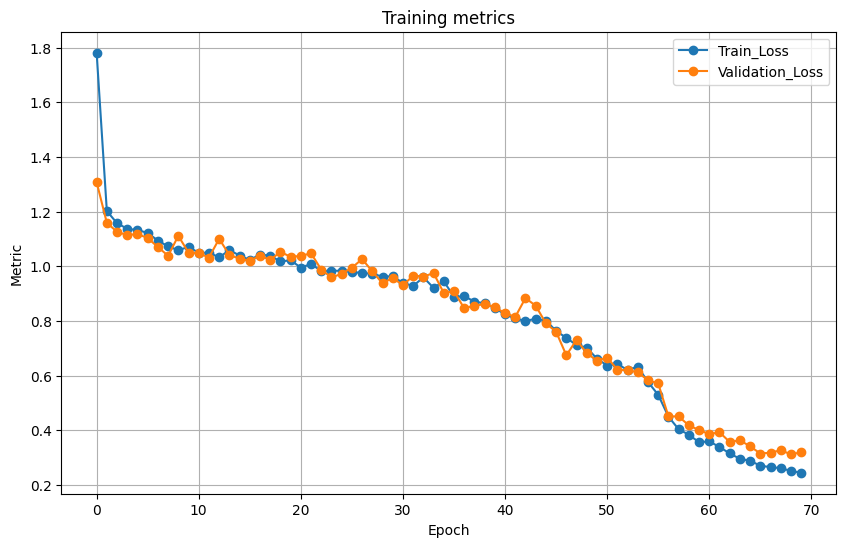

In [16]:
model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True
    )

trained_model = train_ssn_with_validation(
    model=model,
    train_dataset=train_dataset,
    validation_dataset=normal_validation_dataset,
    segmentation_dataset=segmentation_val_dataset,
    classification_dataset=classification_val_dataset,
    num_epochs=70,
    learning_rate=1e-4,
    weight_decay=1e-5,
    device=device,
    log_interval=7,
    log_dir=log_dir,
    batch_size=10,
    resume_from_checkpoint=False,
    freeze_extractor=True,
    early_stopping_patience=12,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min"
)

# Тестирование лучшей обученной модели


In [17]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")


cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [18]:
# Load the trained model from the selected try_N folder.
best_model_path = os.path.join(log_dir, "trained_model.pth")
best_trained_model = torch.load(best_model_path, map_location=device, weights_only=False)
best_trained_model.to(device)
best_trained_model.eval()

test_metrics = {}

# Segmentation/localization test. If no labeled segmentation split is available,
# fall back to synthetic masks generated from held-out normal images.
if segmentation_test_dataset is not None and len(segmentation_test_dataset) > 0:
    anomaly_maps = []
    true_masks = []
    defect_types = []
    with torch.no_grad():
        for i in tqdm(range(len(segmentation_test_dataset)), desc="Segmentation Test", leave=False):
            img, true_mask, defect_type, name = unpack_segmentation_sample(segmentation_test_dataset[i])
            img = img.unsqueeze(0).to(device)
            anomaly_map = predict_anomaly_map(
                best_trained_model,
                img,
                true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                apply_sigmoid=True,
            )
            anomaly_maps.append(anomaly_map)
            true_masks.append(true_mask)
            defect_types.append(defect_type)

    test_metrics["pixel_aupro"] = pixel_aupro(anomaly_maps, true_masks)
    test_metrics.update(pixel_aupro_by_class(anomaly_maps, true_masks, defect_types))

    visualization_dir = os.path.join(log_dir, "test_visualizations")
    save_validation_visualizations(best_trained_model, segmentation_test_dataset, visualization_dir, device=device)
else:
    synthetic_maps = []
    synthetic_masks = []
    fallback_loader = DataLoader(normal_validation_dataset, batch_size=10, shuffle=False, num_workers=0)
    best_trained_model.train()
    with torch.no_grad():
        for batch in tqdm(fallback_loader, desc="Synthetic Segmentation Fallback", leave=False):
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)
            pred_map, _, target_mask, _ = ssn_training_forward(best_trained_model, images)
            for pred, mask in zip(torch.sigmoid(pred_map), target_mask):
                synthetic_maps.append(pred.detach().cpu())
                synthetic_masks.append(mask.detach().cpu())
    best_trained_model.eval()
    test_metrics["synthetic_pixel_aupro"] = pixel_aupro(synthetic_maps, synthetic_masks)

# Image-level detection test. If no labeled classification split is available,
# fall back to synthetic labels generated from held-out normal images.
if classification_test_dataset is not None and len(classification_test_dataset) > 0:
    predicted_scores = []
    true_labels = []
    defect_types = []
    with torch.no_grad():
        for i in tqdm(range(len(classification_test_dataset)), desc="Classification Test", leave=False):
            img, true_label, defect_type, name = unpack_classification_sample(classification_test_dataset[i])
            img = img.unsqueeze(0).to(device)

            anomaly_map = predict_anomaly_map(best_trained_model, img, apply_sigmoid=True)
            img_score = predict_image_score(best_trained_model, img, apply_sigmoid=False)

            predicted_scores.append(img_score)
            true_labels.append(true_label)
            defect_types.append(defect_type)

    if len(set(true_labels)) > 1:
        test_metrics["image_roc_auc_raw"] = roc_auc_score(true_labels, predicted_scores)
        test_metrics.update(image_roc_auc_by_class(predicted_scores, true_labels, defect_types))
else:
    synthetic_scores = []
    synthetic_labels = []
    fallback_loader = DataLoader(normal_validation_dataset, batch_size=10, shuffle=False, num_workers=0)
    best_trained_model.train()
    with torch.no_grad():
        for batch in tqdm(fallback_loader, desc="Synthetic Classification Fallback", leave=False):
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)
            _, pred_score, _, target_label = ssn_training_forward(best_trained_model, images)
            synthetic_scores.extend(pred_score.detach().view(-1).cpu().tolist())
            synthetic_labels.extend(target_label.detach().view(-1).cpu().tolist())
    best_trained_model.eval()
    if len(set(synthetic_labels)) > 1:
        test_metrics["synthetic_image_roc_auc_raw"] = roc_auc_score(synthetic_labels, synthetic_scores)

with open(os.path.join(log_dir, "test_metrics.txt"), "w") as f:
    for metric_name, metric_value in test_metrics.items():
        f.write(f"{metric_name}: {metric_value}\n")

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value}")


synthetic_pixel_aupro: 0.8966774344444275
synthetic_image_roc_auc_raw: 0.9937205651491365
